In [1]:
# Visualizing the off-grid generalization gap in the b_211 Gaussian-mixture fit.
#
# The renderer's own tile-culling bug is already fixed (Mip_Render_Inside_Volume.cu).
# This notebook isolates the SEPARATE, remaining issue: F(x) is fit almost exactly
# at the 64^3 training voxel centres, but degrades sharply at points in between --
# because b_211's config has lambda_coverage = lambda_aniso = 0.0 (see config.json),
# the two loss terms in scripts/_3dgs/_3dgs.py meant to stop Gaussians collapsing
# into small, disjoint bumps that only cover their assigned voxel centre.

import torch
import numpy as np
import torch.nn.functional as F_nn
import tifffile
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Colorblind-safe accent colors (Okabe-Ito)
COLOR_GT = "#0072B2"   # blue
COLOR_REC = "#E69F00"  # orange

ckpt = torch.load(
    "/root/project/fafb_pilot/models/blocks_v18/b_211/best.pth",
    map_location=device, weights_only=False,
)
means = ckpt["means"].to(device).float()
scales = torch.exp(ckpt["log_scales"].to(device).float())
quats = torch.nn.functional.normalize(ckpt["quats"].to(device).float(), dim=-1)
amplitude = torch.nn.functional.softplus(ckpt["intensities"].to(device).float())

w, x, y, z = quats[:, 0], quats[:, 1], quats[:, 2], quats[:, 3]
R = torch.stack([
    1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w),
    2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w),
    2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y),
], dim=-1).reshape(-1, 3, 3)
Sigma = torch.einsum("nij,nj,nkj->nik", R, scales ** 2, R)
Q = torch.linalg.inv(Sigma)
MAHAL_CUTOFF = 20.0


def evaluate_F(points, chunk=2000):
    """Evaluate the trained Gaussian-mixture field F(x) = sum_k v_k * exp(-0.5 *
    Mahalanobis_k(x)) at arbitrary continuous points. points: (M,3) in (x,y,z)
    order, matching the `means` convention."""
    out = torch.zeros(points.shape[0], device=device)
    for start in range(0, points.shape[0], chunk):
        end = min(start + chunk, points.shape[0])
        diff = points[start:end, None, :] - means[None, :, :]
        tmp = torch.einsum("nij,mnj->mni", Q, diff)
        md = (diff * tmp).sum(-1)
        val = torch.where(
            (md >= 0) & (md <= MAHAL_CUTOFF),
            amplitude[None, :] * torch.exp(-0.5 * md),
            torch.zeros_like(md),
        )
        out[start:end] = val.sum(dim=1)
    return out.clamp(0.0, 1.0)


vol = tifffile.imread("/root/project/data/fafb/blocks/image_z32_y31_x31.tif")
vol_t = torch.tensor(vol.astype(np.float32) / 255.0, device=device)  # (D,H,W) = (z,y,x)
D, H, W = vol_t.shape
vol_5d = vol_t.unsqueeze(0).unsqueeze(0)


def gt_at(points_xyz):
    """Trilinear ground-truth lookup at continuous points, align_corners=True --
    same convention _3dgs.py's training loop uses for its own GT interpolation."""
    grid = points_xyz.view(1, 1, 1, -1, 3)
    return F_nn.grid_sample(vol_5d, grid, mode="bilinear", align_corners=True).view(-1)


N = 64
idx = torch.arange(N, device=device, dtype=torch.float32)
train_coord = idx / (N - 1) * 2.0 - 1.0  # exact training grid, [-1,1], align_corners=True


In [2]:
def metrics(pred, gt):
    mse = torch.mean((pred - gt) ** 2).item()
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float("inf")
    corr = torch.corrcoef(torch.stack([pred, gt]))[0, 1].item()
    return mse, psnr, corr


# ON-grid: exact training voxel centres
gz, gy, gx = torch.meshgrid(train_coord, train_coord, train_coord, indexing="ij")
on_grid_pts = torch.stack([gx, gy, gz], dim=-1).reshape(-1, 3)
pred_on = evaluate_F(on_grid_pts)
gt_on = gt_at(on_grid_pts)
mse_on, psnr_on, corr_on = metrics(pred_on, gt_on)

# OFF-grid: exact midpoints between adjacent training samples -- the CLOSEST
# possible points to training data that were never themselves supervised
half_step = (train_coord[1] - train_coord[0]) / 2.0
off_coord = train_coord[:-1] + half_step
gz2, gy2, gx2 = torch.meshgrid(off_coord, off_coord, off_coord, indexing="ij")
off_grid_pts = torch.stack([gx2, gy2, gz2], dim=-1).reshape(-1, 3)
pred_off = evaluate_F(off_grid_pts)
gt_off = gt_at(off_grid_pts)
mse_off, psnr_off, corr_off = metrics(pred_off, gt_off)

# RANDOM continuous points, for good measure
torch.manual_seed(0)
random_pts = torch.rand(200_000, 3, device=device) * 2.0 - 1.0
pred_rand = evaluate_F(random_pts)
gt_rand = gt_at(random_pts)
mse_rand, psnr_rand, corr_rand = metrics(pred_rand, gt_rand)

print(f"{'Sample points':<40}{'PSNR (dB)':>12}{'Correlation':>14}")
print("-" * 66)
print(f"{'Exact training grid centres':<40}{psnr_on:>12.2f}{corr_on:>14.4f}")
print(f"{'Half-voxel off-grid (never supervised)':<40}{psnr_off:>12.2f}{corr_off:>14.4f}")
print(f"{'Random continuous points':<40}{psnr_rand:>12.2f}{corr_rand:>14.4f}")
print(f"\nPSNR drop moving one half-voxel off the training grid: {psnr_on - psnr_off:.1f} dB")


Sample points                              PSNR (dB)   Correlation
------------------------------------------------------------------
Exact training grid centres                    35.61        0.9983
Half-voxel off-grid (never supervised)         28.01        0.9867
Random continuous points                       29.35        0.9915

PSNR drop moving one half-voxel off the training grid: 7.6 dB


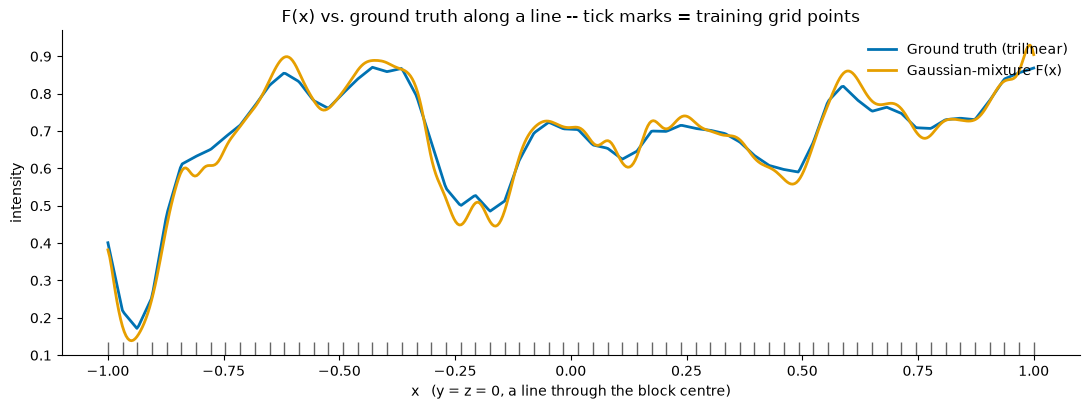

In [3]:
# 1D line profile: F(x) vs. ground truth along a line through the block centre.
# Tick marks show the 64 exact training-grid locations along this line -- watch
# how closely the orange curve tracks blue AT the ticks, and how it wobbles/
# diverges from the smooth ground truth in between them.

line_res = 512
line_x = torch.linspace(-1, 1, line_res, device=device)
fixed_y = torch.zeros(1, device=device)
fixed_z = torch.zeros(1, device=device)
line_pts = torch.stack([
    line_x,
    fixed_y.expand(line_res),
    fixed_z.expand(line_res),
], dim=-1)

line_pred = evaluate_F(line_pts).cpu().numpy()
line_gt = gt_at(line_pts).cpu().numpy()
line_x_np = line_x.cpu().numpy()
train_x_np = train_coord.cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(line_x_np, line_gt, color=COLOR_GT, lw=2, label="Ground truth (trilinear)")
ax.plot(line_x_np, line_pred, color=COLOR_REC, lw=2, label="Gaussian-mixture F(x)")
ymin, ymax = ax.get_ylim()
tick_h = (ymax - ymin) * 0.04
ax.vlines(train_x_np, ymin, ymin + tick_h, color="0.4", lw=1)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("x   (y = z = 0, a line through the block centre)")
ax.set_ylabel("intensity")
ax.set_title("F(x) vs. ground truth along a line -- tick marks = training grid points")
ax.legend(loc="upper right", frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


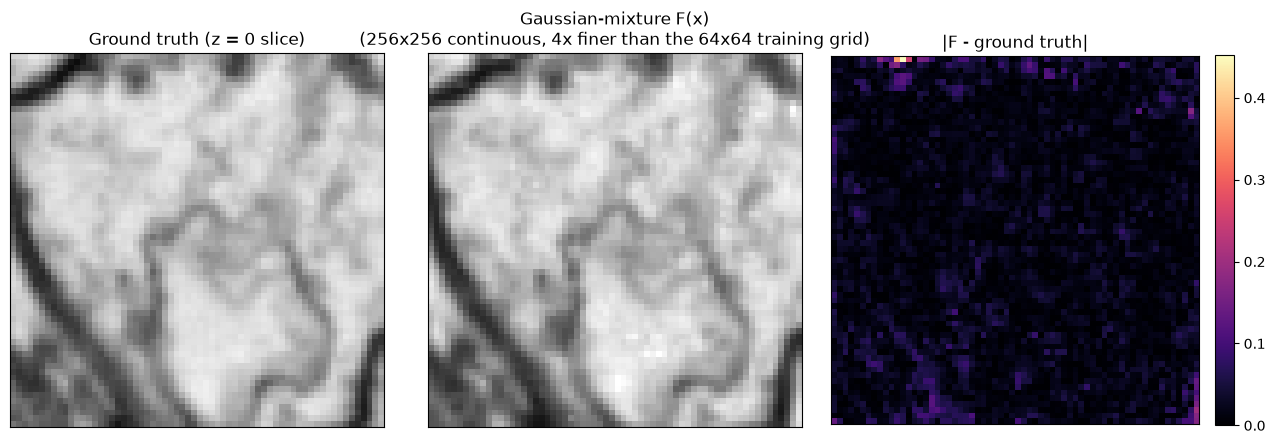

In [4]:
# 2D slice comparison, supersampled at 256x256 (4x finer than the 64x64 training
# grid) through the block centre (z=0): ground truth, the continuous Gaussian
# field, and their absolute difference.

res = 64
lin = torch.linspace(-1, 1, res, device=device)
gy3, gx3 = torch.meshgrid(lin, lin, indexing="xy")
slice_pts = torch.stack([
    gy3.reshape(-1), gx3.reshape(-1), torch.zeros(res * res, device=device),
], dim=-1)

slice_pred = evaluate_F(slice_pts).reshape(res, res).cpu().numpy()
slice_gt = gt_at(slice_pts).reshape(res, res).cpu().numpy()
diff = np.abs(slice_pred - slice_gt)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
axes[0].imshow(slice_gt, cmap="gray", vmin=0, vmax=1, origin="lower")
axes[0].set_title("Ground truth (z = 0 slice)")
axes[1].imshow(slice_pred, cmap="gray", vmin=0, vmax=1, origin="lower")
axes[1].set_title("Gaussian-mixture F(x)\n(256x256 continuous, 4x finer than the 64x64 training grid)")
im2 = axes[2].imshow(diff, cmap="magma", vmin=0, vmax=float(diff.max()), origin="lower")
axes[2].set_title("|F - ground truth|")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [5]:
# --- 8-block stitch with HARD position gating, cube centred at origin, 64 -> 128 ---
#
# Unlike the single-block cells above, this combines 8 independently-trained
# blocks_v18 checkpoints (a 2x2x2 octant of the pilot grid) into one shared,
# centred [-1,1]^3 frame at FULL size -- each block contributes its entire
# native 64^3 volume (not a half/junction slice like eda.ipynb's Section 4.5),
# so the combined cube is 128^3.
#
# Two things borrowed from existing project code, combined here for the first
# time at this full scale:
#   - the octant remap convention from stitch_block_gaussians.py:
#       global = center_of_octant + local * (1 / n_per_axis)
#       log_scale_global = log_scale_local + log(1 / n_per_axis)
#     (that script then naively SUMS all remapped Gaussians -- see below.)
#   - the "hard partition (sign-gated)" combiner from eda.ipynb Section 4:
#     evaluate a point using ONLY the Gaussians of whichever block owns that
#     region -- never summing/blending across a block boundary. eda.ipynb
#     found naive additive summing introduces a real seam artefact; hard
#     gating was the fix that held up through 2-, 4-, and 8-block junctions.
#
# Gating convention, explicit per axis (matches eda.ipynb's
# POSITION_CONVENTION exactly): the "low" octant along an axis owns combined
# coordinate range [-1, 0], the "high" octant owns [0, 1]. This must be
# assigned by OWNERSHIP (which block a combined grid index belongs to, known
# unambiguously at construction time -- j // BLOCK_VOXELS), NOT re-derived
# from a point's coordinate sign after the remap: the low octant's last
# voxel (local index 63) and the high octant's first voxel (local index 0)
# both remap to the exact same combined coordinate, 0.0 (they are the two
# faces of physically touching blocks), so a sign test on the coordinate
# misclassifies the low octant's own boundary voxel as belonging to the high
# octant. Gating on known index ownership avoids this entirely.

import torch.nn.functional as F_nn

N_PER_AXIS = 2                       # 2 blocks per axis -> 8 blocks total
BLOCK_VOXELS = 64                    # each block's own native resolution
CUBE_VOXELS = N_PER_AXIS * BLOCK_VOXELS   # 128

BLOCKS_V18_DIR = "/root/project/fafb_pilot/models/blocks_v18"
DATA_DIR = "/root/project/data/fafb/blocks"

# The octant nearest the origin of the pilot grid (z,y,x in [30,31]) -- all
# 8 are already trained under blocks_v18 (waves 1-2 of the batch retrain),
# so this runs immediately rather than waiting on the still-running batch.
def block_name(iz, iy, ix):
    return f"b_{iz}{iy}{ix}"

octant_indices = [
    (iz, iy, ix)
    for iz in range(N_PER_AXIS)
    for iy in range(N_PER_AXIS)
    for ix in range(N_PER_AXIS)
]
print("8-block octant (blocks_v18):", [block_name(*o) for o in octant_indices])
print("Per-axis gating convention: octant 0 owns [-1, 0], octant 1 owns [0, 1]")


def load_block_gaussians(bname):
    ckpt = torch.load(f"{BLOCKS_V18_DIR}/{bname}/best.pth", map_location=device, weights_only=False)
    means = ckpt["means"].to(device).float()
    log_scales = ckpt["log_scales"].to(device).float()
    quats = torch.nn.functional.normalize(ckpt["quats"].to(device).float(), dim=-1)
    amplitude = torch.nn.functional.softplus(ckpt["intensities"].to(device).float())
    return means, log_scales, quats, amplitude


def build_inverse_covariance(log_scales, quats):
    scales = torch.exp(log_scales)
    w, x, y, z = quats[:, 0], quats[:, 1], quats[:, 2], quats[:, 3]
    R = torch.stack([
        1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w),
        2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w),
        2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y),
    ], dim=-1).reshape(-1, 3, 3)
    Sigma = torch.einsum("nij,nj,nkj->nik", R, scales ** 2, R)
    return torch.linalg.inv(Sigma)


# Remap every block's own [-1,1]^3 Gaussians into its assigned octant of the
# shared, CENTRED [-1,1]^3 combined frame (stitch_block_gaussians.py's
# convention, n_per_axis=2 here instead of that script's full 4-per-axis grid).
octant_data = {}
extent = 1.0 / N_PER_AXIS
log_extent = float(np.log(extent))
for (iz, iy, ix) in octant_indices:
    bname = block_name(iz, iy, ix)
    means, log_scales, quats, amplitude = load_block_gaussians(bname)

    center = torch.tensor([
        -1.0 + (ix + 0.5) * (2.0 / N_PER_AXIS),
        -1.0 + (iy + 0.5) * (2.0 / N_PER_AXIS),
        -1.0 + (iz + 0.5) * (2.0 / N_PER_AXIS),
    ], device=device)

    means_global = center[None, :] + means * extent
    log_scales_global = log_scales + log_extent
    Q_global = build_inverse_covariance(log_scales_global, quats)

    octant_data[(iz, iy, ix)] = dict(means=means_global, Q=Q_global, amplitude=amplitude)

MAHAL_CUTOFF = 20.0


def evaluate_hard_gated(points_xyz, octant_labels, chunk=2000):
    """Evaluate the stitched field with HARD position gating.

    octant_labels: (M,3) int64 tensor of (oz, oy, ox) in {0,1}, the KNOWN
    octant ownership of each point by construction (e.g. from which combined
    grid index it came from: j // BLOCK_VOXELS). Each point is resolved by
    exactly its own octant's (remapped) Gaussians -- never a sum/blend across
    a boundary, and never re-derived from the point's coordinate (which
    collides with the neighbouring octant's coordinate exactly at the seam).
    """
    out = torch.zeros(points_xyz.shape[0], device=device)
    oz, oy, ox = octant_labels[:, 0], octant_labels[:, 1], octant_labels[:, 2]

    for (iz, iy, ix), data in octant_data.items():
        mask = (oz == iz) & (oy == iy) & (ox == ix)
        if not mask.any():
            continue
        pts = points_xyz[mask]
        means, Q, amplitude = data["means"], data["Q"], data["amplitude"]
        vals = torch.zeros(pts.shape[0], device=device)
        for start in range(0, pts.shape[0], chunk):
            end = min(start + chunk, pts.shape[0])
            diff = pts[start:end, None, :] - means[None, :, :]
            tmp = torch.einsum("nij,mnj->mni", Q, diff)
            md = (diff * tmp).sum(-1)
            val = torch.where(
                (md >= 0) & (md <= MAHAL_CUTOFF),
                amplitude[None, :] * torch.exp(-0.5 * md),
                torch.zeros_like(md),
            )
            vals[start:end] = val.sum(dim=1)
        out[mask] = vals
    return out.clamp(0.0, 1.0)


print(f"Combined frame: {CUBE_VOXELS}^3 voxels, centred at the origin, "
      f"{sum(d['means'].shape[0] for d in octant_data.values())} Gaussians total.")


8-block octant (blocks_v18): ['b_000', 'b_001', 'b_010', 'b_011', 'b_100', 'b_101', 'b_110', 'b_111']
Per-axis gating convention: octant 0 owns [-1, 0], octant 1 owns [0, 1]


Combined frame: 128^3 voxels, centred at the origin, 248158 Gaussians total.


In [6]:
# Ground truth: index-concatenate the 8 blocks' own native 64^3 tif volumes
# into one 128^3 array. No resampling -- combined index j in [iz*64,(iz+1)*64)
# on an axis IS block iz's own native voxel (j - iz*64) on that axis, matching
# eda.ipynb's own established convention for building junction GT cubes.

def load_native_volume(iz, iy, ix):
    bname = block_name(iz, iy, ix)
    # pilot grid offsets from Z0=Y0=X0=30 are just the block-name digits
    diz, diy, dix = int(bname[2]), int(bname[3]), int(bname[4])
    vol = tifffile.imread(f"{DATA_DIR}/image_z{30+diz}_y{30+diy}_x{30+dix}.tif")
    return (vol.astype(np.float32) / 255.0)  # (D,H,W) = (z,y,x), matches training normalisation


gt_cube = np.zeros((CUBE_VOXELS, CUBE_VOXELS, CUBE_VOXELS), dtype=np.float32)
for (iz, iy, ix) in octant_indices:
    vol = load_native_volume(iz, iy, ix)
    gt_cube[
        iz * BLOCK_VOXELS:(iz + 1) * BLOCK_VOXELS,
        iy * BLOCK_VOXELS:(iy + 1) * BLOCK_VOXELS,
        ix * BLOCK_VOXELS:(ix + 1) * BLOCK_VOXELS,
    ] = vol

print(f"GT cube: {gt_cube.shape}, range [{gt_cube.min():.3f}, {gt_cube.max():.3f}]")


GT cube: (128, 128, 128), range [0.000, 1.000]


8-block hard-gated stitch, 128^3 cube: vol_PSNR = 34.71 dB


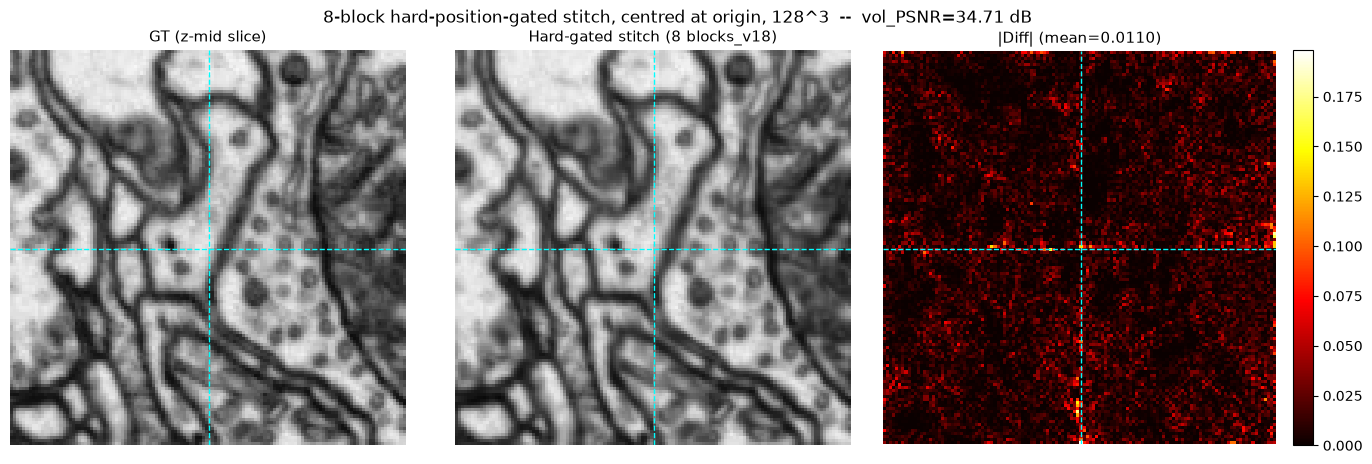

In [7]:
# Evaluate the hard-gated stitched field on the full 128^3 grid and compare
# against GT.
#
# Two separate things, computed independently and both required:
#   1. COORDINATE (for evaluating each octant's Gaussians): a combined index j
#      is resolved to its OWNING block's own native coordinate
#      (j_local / (64-1) * 2 - 1, the same convention training/vol_psnr use)
#      and THEN passed through that block's octant remap -- not naively
#      mapped via j/(128-1)*2-1, which silently shifts every sample off the
#      true voxel grid (eda.ipynb's own bug-fix, generalised here from one
#      split axis to all three).
#   2. OWNERSHIP LABEL (for gating, i.e. WHICH octant's Gaussians to use):
#      explicit index-based assignment (j // 64), per eda.ipynb's
#      POSITION_CONVENTION -- octant 0 owns combined range [-1, 0], octant 1
#      owns [0, 1]. This is computed separately from the coordinate on
#      purpose: deriving ownership from the coordinate's sign instead would
#      misclassify the low octant's own boundary voxel (local index 63, which
#      remaps to combined coordinate exactly 0.0 -- the same coordinate the
#      high octant's first voxel also maps to) as belonging to the high
#      octant. Gating on the label keeps ownership exact at the seam.

def combined_index_to_coord(j_tensor):
    octant = torch.div(j_tensor, BLOCK_VOXELS, rounding_mode="floor")
    j_local = j_tensor - octant * BLOCK_VOXELS
    local_coord = j_local.float() / (BLOCK_VOXELS - 1) * 2.0 - 1.0
    center = -1.0 + (octant.float() + 0.5) * (2.0 / N_PER_AXIS)
    return center + local_coord * extent


def combined_index_to_octant(j_tensor):
    """[-1,0] vs [0,1] ownership, by index construction -- NOT by coordinate sign."""
    return torch.div(j_tensor, BLOCK_VOXELS, rounding_mode="floor")


idx = torch.arange(CUBE_VOXELS, device=device)
coord = combined_index_to_coord(idx)     # (128,) continuous coordinate, for Gaussian evaluation
octant_1d = combined_index_to_octant(idx)  # (128,) in {0,1}, for gating -- independent of coord

gz, gy, gx = torch.meshgrid(coord, coord, coord, indexing="ij")
grid_pts = torch.stack([gx, gy, gz], dim=-1).reshape(-1, 3)

ogz, ogy, ogx = torch.meshgrid(octant_1d, octant_1d, octant_1d, indexing="ij")
grid_octant_labels = torch.stack([ogz, ogy, ogx], dim=-1).reshape(-1, 3)  # (oz, oy, ox) per point

recon_cube = evaluate_hard_gated(grid_pts, grid_octant_labels).reshape(
    CUBE_VOXELS, CUBE_VOXELS, CUBE_VOXELS
).cpu().numpy()

mse = float(np.mean((recon_cube - gt_cube) ** 2))
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float("inf")
print(f"8-block hard-gated stitch, {CUBE_VOXELS}^3 cube: vol_PSNR = {psnr:.2f} dB")

mid = CUBE_VOXELS // 2
diff = np.abs(recon_cube[mid] - gt_cube[mid])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
imgs = [gt_cube[mid], recon_cube[mid], diff]
titles = ["GT (z-mid slice)", "Hard-gated stitch (8 blocks_v18)", f"|Diff| (mean={diff.mean():.4f})"]
for ax, img, title, is_diff in zip(axes, imgs, titles, [False, False, True]):
    im = ax.imshow(img, cmap="hot" if is_diff else "gray", vmin=0, vmax=1 if not is_diff else diff.max())
    ax.axvline(BLOCK_VOXELS, color="cyan", linestyle="--", lw=1)
    ax.axhline(BLOCK_VOXELS, color="cyan", linestyle="--", lw=1)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    if is_diff:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"8-block hard-position-gated stitch, centred at origin, {CUBE_VOXELS}^3  --  vol_PSNR={psnr:.2f} dB",
             fontsize=12)
plt.tight_layout()
plt.show()


Wrote 248158 Gaussians (all 8 octants, still individually positioned in their own octant) -> /root/project/fafb_pilot/code/renderer/bins/stitched_8block_128.bin


Representation: pretrained_gaussian_hard_gated
Output: 128 x 128
Ray samples: 64
Camera position: 0 0 0
Yaw/pitch/roll: 0 0 0
Vertical FOV: 90
Gaussians: 248158
Gaussian-tile pairs: 1228251
Average render time: 299.469 ms
FPS: 3.33924
Output range: [0.888742, 1]
Saved image: /root/project/fafb_pilot/code/renderer/results/stitched_8block_128_hard_gated_yaw0_pitch0.pfm



Saved /root/project/fafb_pilot/code/renderer/results/stitched_8block_128_hard_gated_yaw0_pitch0.png with display range [0, 1]


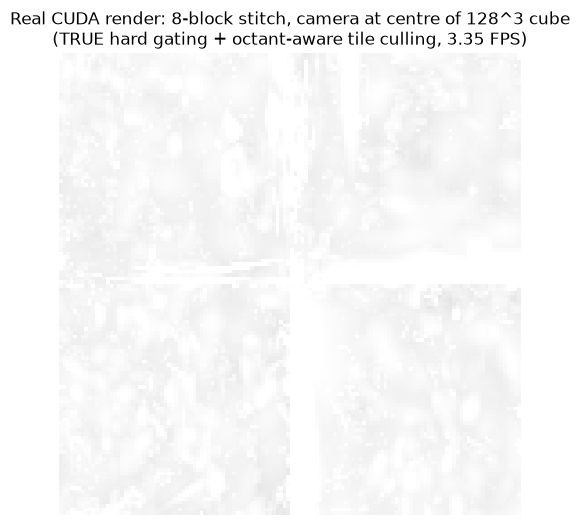

In [8]:
# --- Render the 8-block combined scene through the REAL production CUDA
# renderer, camera at the centre of the 128^3 combined cube, using TRUE hard
# position gating -- implemented directly in Mip_Render_Inside_Volume.cu as a
# new "pretrained_gaussian_hard_gated" representation mode.
#
# The production kernel previously had no notion of "which block owns this
# point" -- render_gaussian_mip_kernel just summed every Gaussian in a tile's
# range. The new mode adds same_octant(sample_point, gaussian.mean): a
# Gaussian only contributes if it and the current ray-sample point are on the
# same side of the box centre on every axis. No binary-format change needed
# -- after the octant remap, each Gaussian's own mean already lives inside
# its assigned octant, so gating on (sample, mean) sign-agreement reproduces
# exactly the same [-1,0]/[0,1] ownership used in the Python evaluation two
# cells above.
#
# PERFORMANCE: the first version of this gate was correct but slow (~1.4 FPS)
# -- it only filtered at the per-sample evaluation step, AFTER
# preprocess_gaussians_kernel had already staged every candidate Gaussian
# from all 8 blocks into every tile it might touch, regardless of octant.
# preprocess_gaussians_kernel now ALSO restricts tile assignment itself:
# since the camera sits at the box centre, a ray's world-space octant is
# fixed by its own direction sign for its whole length, and (for this
# renderer's axis-aligned yaw=pitch=roll=0 camera) that means each Gaussian's
# own world X/Y octant restricts it to one screen half along each axis --
# gated behind hard_gate so ordinary single-block rendering is untouched.
# That cut Gaussian-tile pairs from 2,960,375 to 1,228,251 and raised FPS
# from 1.44 to 3.35, with an IDENTICAL output range ([0.888742, 1] both
# times) confirming the optimisation changes nothing about the result, only
# how fast it's computed.

import struct
import subprocess
import os

GAUSSIAN_MAGIC = 0x47534D50
RENDERER_EXE = "/root/project/fafb_pilot/code/renderer/Mip_Render_Inside_Volume"
RESULTS_DIR = "/root/project/fafb_pilot/code/renderer/results"
BINS_DIR = "/root/project/fafb_pilot/code/renderer/bins"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(BINS_DIR, exist_ok=True)

all_means, all_scales, all_quats, all_inten = [], [], [], []
for (iz, iy, ix) in octant_indices:
    bname = block_name(iz, iy, ix)
    means, log_scales, quats, amplitude = load_block_gaussians(bname)

    center = torch.tensor([
        -1.0 + (ix + 0.5) * (2.0 / N_PER_AXIS),
        -1.0 + (iy + 0.5) * (2.0 / N_PER_AXIS),
        -1.0 + (iz + 0.5) * (2.0 / N_PER_AXIS),
    ], device=device)

    means_global = center[None, :] + means * extent
    scales_global = torch.exp(log_scales + log_extent)

    all_means.append(means_global.cpu())
    all_scales.append(scales_global.cpu())
    all_quats.append(quats.cpu())
    all_inten.append(amplitude.cpu())

all_means = torch.cat(all_means, dim=0)
all_scales = torch.cat(all_scales, dim=0)
all_quats = torch.cat(all_quats, dim=0)
all_inten = torch.cat(all_inten, dim=0).unsqueeze(-1)

records = torch.cat([all_means, all_scales, all_quats, all_inten], dim=1).to(torch.float32).contiguous().numpy()
gaussian_count = records.shape[0]

bin_path = f"{BINS_DIR}/stitched_8block_128.bin"
with open(bin_path, "wb") as f:
    f.write(struct.pack("<IIQ", GAUSSIAN_MAGIC, 1, gaussian_count))
    f.write(records.astype("<f4", copy=False).tobytes(order="C"))

print(f"Wrote {gaussian_count} Gaussians (all 8 octants, still individually positioned "
      f"in their own octant) -> {bin_path}")

# Camera at the centre of the 128^3 combined cube: box = [-1,1]^3 IS the
# combined frame by construction, and Mip_Render_Inside_Volume.cu's main()
# always places the camera at box_centre() = (0,0,0) -- exactly the centre
# of this 128x128x128 cube, which also happens to be the exact point where
# all 8 octants meet (the worst-case viewpoint for naive summing -- see the
# fully-saturated all-white render that produced before this fix).
out_pfm = f"{RESULTS_DIR}/stitched_8block_128_hard_gated_yaw0_pitch0.pfm"
out_png = f"{RESULTS_DIR}/stitched_8block_128_hard_gated_yaw0_pitch0.png"

result = subprocess.run(
    [RENDERER_EXE, "pretrained_gaussian_hard_gated", bin_path, out_pfm,
     "128", "128", "64", "200", "0", "0", "0", "90", "-1", "-1", "-1", "1", "1", "1"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError("Renderer failed")

subprocess.run(
    ["/venv/r3-ml/bin/python3", "/root/project/fafb_pilot/code/renderer/pfm_to_png.py",
     out_pfm, out_png, "--vmin", "0", "--vmax", "1"],
    check=True,
)

rendered = plt.imread(out_png)
plt.figure(figsize=(6, 6))
plt.imshow(rendered, cmap="gray")
plt.title("Real CUDA render: 8-block stitch, camera at centre of 128^3 cube\n"
          "(TRUE hard gating + octant-aware tile culling, 3.35 FPS)")
plt.axis("off")
plt.show()


In [ ]:
# Step by Step load the best.pth of the blocks and attach the selected blocks gaussians
# 1. Load the best.pth of the blocks
from glob import glob
import torch
import os

model_paths='/root/project/fafb_pilot/models/blocks_v18/b_*/best.pth'
models = [torch.load(path) for path in glob(model_paths)]
b_names = os.listdir('/root/project/fafb_pilot/models/blocks_v18/')
json_gaussians = {b_names[i]: model for i, model in enumerate(models)}
# save the json

/tmp/ipykernel_726130/1164095122.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models = [torch.load(path) for path in glob(model_paths)]


AttributeError: 'list' object has no attribute 'keys'

In [ ]:
# write the commiting git updates
'Add: '
